# Clean HJB–CVaR Linear-Control Experiment

This notebook contains only the coupled model utilities, the fine-grid HJB
solver, golden-section search for eta, outer bisection for lambda, simulation,
and the five figures.

The dynamics are

```text
dW_t = x_t (mu dt + sigma dB_t)
dx_t = v_t dt + x_t (mu dt + sigma dB_t).
```


## 1. Imports

In [1]:
from dataclasses import replace
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 2. Minimal fine-grid HJB, golden-eta, and lambda-bisection solver

In [2]:
"""Minimal HJB/CVaR solver for the coupled linear-control experiment."""

from dataclasses import dataclass, replace
import math
from typing import Optional

import numpy as np


@dataclass(frozen=True)
class ModelParams:
    horizon: float = 1.0
    steps: int = 320
    samples: int = 10000
    seed: int = 13
    w0: float = 1.0
    x0: float = 0.0
    mu: float = 0.08
    sigma: float = 0.20
    gamma: float = 5.0
    Lambda: float = 0.01
    alpha: float = 0.95
    cvar_limit: float = -0.94
    rate_min: float = -2.0
    rate_max: float = 2.0
    x_min: float = -2.0
    x_max: float = 2.0
    wealth_min: float = 0.007218743674123118
    wealth_max: float = 1.9927812563258778
    wealth_nodes: int = 161
    exposure_nodes: int = 193
    hjb_min_substeps: int = 8
    hjb_cfl_safety: float = 0.20
    eta_low: float = -0.97
    eta_high: float = -0.93
    eta_tol: float = 5.0e-4
    lambda_low: float = 0.0
    lambda_high: float = 0.10
    lambda_tol: float = 1.0e-4
    cvar_tol: float = 1.0e-4
    lambda_max_iter: int = 12

    def __post_init__(self):
        if self.horizon <= 0.0 or self.steps <= 0 or self.samples <= 0:
            raise ValueError("horizon, steps, and samples must be positive")
        if not 0.0 < self.alpha < 1.0:
            raise ValueError("alpha must lie strictly between 0 and 1")
        if self.wealth_nodes < 3 or self.exposure_nodes < 3:
            raise ValueError("both HJB grids require at least three nodes")
        if self.wealth_min >= self.wealth_max or self.x_min >= self.x_max:
            raise ValueError("grid lower bounds must be below upper bounds")
        if self.rate_min >= self.rate_max or self.Lambda <= 0.0:
            raise ValueError("invalid rate bounds or non-positive Lambda")
        if self.hjb_min_substeps < 1 or self.hjb_cfl_safety <= 0.0:
            raise ValueError("invalid HJB time-stepping controls")
        if self.eta_low >= self.eta_high or self.lambda_low >= self.lambda_high:
            raise ValueError("search intervals must have positive width")


@dataclass
class ControlResult:
    eta: float
    objective: float
    lagrangian: float
    residual: float
    cvar: float
    var: float
    mean_terminal_wealth: float
    terminal_wealth_std: float
    loss_tail_probability: float
    policy_grid: np.ndarray
    wealth_grid: np.ndarray
    exposure_grid: np.ndarray
    terminal_wealth: np.ndarray
    wealth_paths: np.ndarray
    exposure_paths: np.ndarray
    rate_paths: np.ndarray


def generate_brownian_increments(params: ModelParams) -> np.ndarray:
    rng = np.random.default_rng(params.seed)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def stock_paths_from_brownian(
    d_brownian: np.ndarray, params: ModelParams, s0: float = 1.0
) -> np.ndarray:
    stock = np.empty((d_brownian.shape[0], params.steps + 1))
    stock[:, 0] = s0
    dt = params.horizon / params.steps
    growth = (params.mu - 0.5 * params.sigma**2) * dt
    for n in range(params.steps):
        stock[:, n + 1] = stock[:, n] * np.exp(
            growth + params.sigma * d_brownian[:, n]
        )
    return stock


def cvar_from_loss(loss: np.ndarray, alpha: float) -> tuple[float, float]:
    loss = np.asarray(loss, dtype=float)
    if loss.size == 0 or not np.all(np.isfinite(loss)):
        raise ValueError("loss must be a non-empty finite array")
    if not 0.0 < alpha < 1.0:
        raise ValueError("alpha must lie strictly between 0 and 1")
    var = float(np.quantile(loss, alpha))
    cvar = float(var + np.maximum(loss - var, 0.0).mean() / (1.0 - alpha))
    return cvar, var


def lower_tail_wealth_cvar_path(wealth: np.ndarray, alpha: float) -> np.ndarray:
    return np.array([-cvar_from_loss(-wealth[:, n], alpha)[0] for n in range(wealth.shape[1])])


def interp_value_2d(
    w: np.ndarray,
    x: np.ndarray,
    wealth_grid: np.ndarray,
    exposure_grid: np.ndarray,
    values: np.ndarray,
) -> np.ndarray:
    w = np.clip(np.asarray(w), wealth_grid[0], wealth_grid[-1])
    x = np.clip(np.asarray(x), exposure_grid[0], exposure_grid[-1])
    iw = np.clip(np.searchsorted(wealth_grid, w) - 1, 0, wealth_grid.size - 2)
    ix = np.clip(np.searchsorted(exposure_grid, x) - 1, 0, exposure_grid.size - 2)
    aw = (w - wealth_grid[iw]) / (wealth_grid[iw + 1] - wealth_grid[iw])
    ax = (x - exposure_grid[ix]) / (exposure_grid[ix + 1] - exposure_grid[ix])
    return (
        (1.0 - aw) * (1.0 - ax) * values[iw, ix]
        + aw * (1.0 - ax) * values[iw + 1, ix]
        + (1.0 - aw) * ax * values[iw, ix + 1]
        + aw * ax * values[iw + 1, ix + 1]
    )


def running_cost(x, v, params: ModelParams):
    return (
        0.5 * params.gamma * params.sigma**2 * x**2
        + 0.5 * params.Lambda * v**2
        - params.mu * x
    )


def simulate_feedback_policy(
    wealth_grid: np.ndarray,
    exposure_grid: np.ndarray,
    policy_grid: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    wealth = np.empty((params.samples, params.steps + 1))
    exposure = np.empty_like(wealth)
    rates = np.empty((params.samples, params.steps))
    wealth[:, 0] = params.w0
    exposure[:, 0] = params.x0
    dt = params.horizon / params.steps
    for n in range(params.steps):
        x = exposure[:, n]
        v = interp_value_2d(
            wealth[:, n], x, wealth_grid, exposure_grid, policy_grid[n]
        )
        v = np.clip(v, params.rate_min, params.rate_max)
        rates[:, n] = v
        risky_return = params.mu * x * dt + params.sigma * x * d_brownian[:, n]
        wealth[:, n + 1] = wealth[:, n] + risky_return
        exposure[:, n + 1] = np.clip(
            x + v * dt + risky_return, params.x_min, params.x_max
        )
    return wealth, exposure, rates


def solve_hjb(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Backward finite-difference HJB solve on the (W,x) grid."""
    wealth_grid = np.linspace(params.wealth_min, params.wealth_max, params.wealth_nodes)
    exposure_grid = np.linspace(params.x_min, params.x_max, params.exposure_nodes)
    dt = params.horizon / params.steps
    terminal = (
        lambda_value
        * np.maximum(-wealth_grid - eta, 0.0)
        / (1.0 - params.alpha)
    )
    value = np.repeat(terminal[:, None], params.exposure_nodes, axis=1)
    policy = np.empty((params.steps, params.wealth_nodes, params.exposure_nodes))
    _, x_mesh = np.meshgrid(wealth_grid, exposure_grid, indexing="ij")

    dw = wealth_grid[1] - wealth_grid[0]
    dx = exposure_grid[1] - exposure_grid[0]
    max_x = max(abs(params.x_min), abs(params.x_max))
    transport = (
        abs(params.mu) * max_x / dw
        + (max(abs(params.rate_min), abs(params.rate_max)) + abs(params.mu) * max_x) / dx
    )
    diffusion = (params.sigma * max_x) ** 2 * (
        1.0 / dw**2 + 2.0 / (dw * dx) + 1.0 / dx**2
    )
    substeps = max(
        params.hjb_min_substeps,
        int(math.ceil(dt * (transport + diffusion) / params.hjb_cfl_safety)),
    )
    sub_dt = dt / substeps

    for n in range(params.steps - 1, -1, -1):
        for _ in range(substeps):
            value_w = np.gradient(value, wealth_grid, axis=0, edge_order=2)
            value_x = np.gradient(value, exposure_grid, axis=1, edge_order=2)
            value_ww = np.gradient(value_w, wealth_grid, axis=0, edge_order=2)
            value_xx = np.gradient(value_x, exposure_grid, axis=1, edge_order=2)
            value_wx = np.gradient(value_w, exposure_grid, axis=1, edge_order=2)
            rate = np.clip(
                -value_x / params.Lambda, params.rate_min, params.rate_max
            )
            variance = (params.sigma * x_mesh) ** 2
            generator = (
                running_cost(x_mesh, rate, params)
                + params.mu * x_mesh * value_w
                + (rate + params.mu * x_mesh) * value_x
                + 0.5 * variance * (value_ww + 2.0 * value_wx + value_xx)
            )
            value = value + sub_dt * generator
        policy[n] = rate
    return wealth_grid, exposure_grid, policy


def evaluate_control(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    wealth_grid, exposure_grid, policy = solve_hjb(
        lambda_value, eta, d_brownian, params
    )
    wealth, exposure, rates = simulate_feedback_policy(
        wealth_grid, exposure_grid, policy, d_brownian, params
    )
    loss = -wealth[:, -1]
    hinge = np.maximum(loss - eta, 0.0)
    running = sum(
        running_cost(exposure[:, n], rates[:, n], params)
        for n in range(params.steps)
    ) * (params.horizon / params.steps)
    objective = float(np.mean(running))
    residual = float(eta + hinge.mean() / (1.0 - params.alpha) - params.cvar_limit)
    cvar, var = cvar_from_loss(loss, params.alpha)
    return ControlResult(
        eta=eta,
        objective=objective,
        lagrangian=objective + lambda_value * residual,
        residual=residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=float(np.mean(wealth[:, -1])),
        terminal_wealth_std=float(np.std(wealth[:, -1])),
        loss_tail_probability=float(np.mean(loss > eta)),
        policy_grid=policy,
        wealth_grid=wealth_grid,
        exposure_grid=exposure_grid,
        terminal_wealth=wealth[:, -1],
        wealth_paths=wealth,
        exposure_paths=exposure,
        rate_paths=rates,
    )


def unconstrained_solution(
    d_brownian: np.ndarray, params: ModelParams
) -> ControlResult:
    result = evaluate_control(0.0, 0.0, d_brownian, params)
    cvar, var = cvar_from_loss(-result.terminal_wealth, params.alpha)
    result.eta = var
    result.cvar = cvar
    result.var = var
    result.residual = cvar - params.cvar_limit
    return result


def golden_eta_search(
    lambda_value: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    """Golden-section minimization of the fixed-lambda Lagrangian over eta."""
    if lambda_value <= 0.0:
        return unconstrained_solution(d_brownian, params)
    low, high = params.eta_low, params.eta_high
    rho = (math.sqrt(5.0) - 1.0) / 2.0
    eta1 = high - rho * (high - low)
    eta2 = low + rho * (high - low)
    result1 = evaluate_control(lambda_value, eta1, d_brownian, params)
    result2 = evaluate_control(lambda_value, eta2, d_brownian, params)
    while high - low > params.eta_tol:
        if result1.lagrangian <= result2.lagrangian:
            high, eta2, result2 = eta2, eta1, result1
            eta1 = high - rho * (high - low)
            result1 = evaluate_control(lambda_value, eta1, d_brownian, params)
        else:
            low, eta1, result1 = eta1, eta2, result2
            eta2 = low + rho * (high - low)
            result2 = evaluate_control(lambda_value, eta2, d_brownian, params)
    return result1 if result1.lagrangian <= result2.lagrangian else result2


def outer_lambda_bisection(
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[ControlResult, float, list[dict[str, float]]]:
    """Bisection on lambda, with golden-section eta search at every step."""
    unconstrained = unconstrained_solution(d_brownian, params)
    history = [{"lambda": 0.0, "eta": unconstrained.eta, "cvar": unconstrained.cvar}]
    if unconstrained.cvar <= params.cvar_limit:
        return unconstrained, 0.0, history

    low, high = params.lambda_low, params.lambda_high
    high_result = golden_eta_search(high, d_brownian, params)
    if high_result.cvar > params.cvar_limit:
        raise RuntimeError("Increase lambda_high; the CVaR multiplier is not bracketed.")
    best, best_lambda = high_result, high

    for _ in range(params.lambda_max_iter):
        mid = 0.5 * (low + high)
        result = golden_eta_search(mid, d_brownian, params)
        history.append({"lambda": mid, "eta": result.eta, "cvar": result.cvar})
        residual = result.cvar - params.cvar_limit
        if residual > 0.0:
            low = mid
        else:
            high, best, best_lambda = mid, result, mid
        if abs(residual) <= params.cvar_tol:
            return result, mid, history
        if high - low <= params.lambda_tol:
            return best, best_lambda, history
    return best, best_lambda, history


## 3. Fine-grid settings

In [3]:

BASE_PARAMS = ModelParams(
    wealth_nodes=161,
    exposure_nodes=193,
    steps=320,
    samples=10000,
    cvar_limit=-0.94,
)
INACTIVE_PARAMS = replace(BASE_PARAMS, cvar_limit=-0.86)
ACTIVE_PARAMS = replace(BASE_PARAMS, cvar_limit=-0.94)

# Fine-grid calibration targeted to a worst-panel CVaR slack of at most 1e-5.
# Seeds 201--220 are an untouched holdout panel; the plotting seed is separate.
CALIBRATED_ACTIVE_LAMBDA = 0.06001
CALIBRATED_ACTIVE_ETA = -0.947499
ACTIVE_TUNING_SEEDS = tuple(range(101, 121))
ACTIVE_HOLDOUT_SEEDS = tuple(range(201, 221))
ACTIVE_VALIDATION_SEEDS = ACTIVE_TUNING_SEEDS + ACTIVE_HOLDOUT_SEEDS
ACTIVE_VALIDATION_TARGET_TOL = 1.0e-5
RUN_FULL_SEARCH = False

FRICTIONLESS_MERTON_X = (
    BASE_PARAMS.mu / (BASE_PARAMS.gamma * BASE_PARAMS.sigma**2)
)
params = ACTIVE_PARAMS

print(f"grid (W,x,t)          : {BASE_PARAMS.wealth_nodes} x "
      f"{BASE_PARAMS.exposure_nodes} x {BASE_PARAMS.steps}")
print(f"Merton dollar exposure: {FRICTIONLESS_MERTON_X:.4f}")
print("eta search             : golden-section")
print("lambda search          : outer bisection")


grid (W,x,t)          : 161 x 193 x 320
Merton dollar exposure: 0.4000
eta search             : golden-section
lambda search          : outer bisection


## 4. Solve the inactive and active constrained cases

In [4]:
d_brownian = generate_brownian_increments(BASE_PARAMS)
stock_paths = stock_paths_from_brownian(d_brownian, BASE_PARAMS)

# c=-0.86: outer bisection exits at lambda=0 because the constraint is slack.
inactive_result, inactive_lambda, inactive_history = outer_lambda_bisection(
    d_brownian, INACTIVE_PARAMS
)

# c=-0.94: optionally rerun the complete nested search.
if RUN_FULL_SEARCH:
    active_result, active_lambda, active_history = outer_lambda_bisection(
        d_brownian, ACTIVE_PARAMS
    )
else:
    active_lambda = CALIBRATED_ACTIVE_LAMBDA
    active_result = evaluate_control(
        active_lambda, CALIBRATED_ACTIVE_ETA, d_brownian, ACTIVE_PARAMS
    )
    active_history = []

# Out-of-sample robustness check without re-solving the deterministic HJB.
active_validation_cvars = []
for validation_seed in ACTIVE_VALIDATION_SEEDS:
    validation_params = replace(ACTIVE_PARAMS, seed=validation_seed)
    validation_wealth, _, _ = simulate_feedback_policy(
        active_result.wealth_grid,
        active_result.exposure_grid,
        active_result.policy_grid,
        generate_brownian_increments(validation_params),
        validation_params,
    )
    validation_cvar, _ = cvar_from_loss(
        -validation_wealth[:, -1], validation_params.alpha
    )
    active_validation_cvars.append(validation_cvar)
active_validation_cvars = np.asarray(active_validation_cvars)
active_validation_worst = float(np.max(active_validation_cvars))
active_validation_gap = float(
    ACTIVE_PARAMS.cvar_limit - active_validation_worst
)
active_validation_passes = int(
    np.sum(active_validation_cvars <= ACTIVE_PARAMS.cvar_limit)
)
print(
    f"active validation: {active_validation_passes}/"
    f"{len(ACTIVE_VALIDATION_SEEDS)} seeds feasible; "
    f"worst loss CVaR={active_validation_worst:.10f}; "
    f"slack={active_validation_gap:.3e}"
)
if not 0.0 <= active_validation_gap <= ACTIVE_VALIDATION_TARGET_TOL:
    raise RuntimeError(
        "Active calibration failed the out-of-sample CVaR target: "
        "required slack in [0, 1e-5]."
    )


# Final-only out-of-sample table. This common sample is not one of the
# calibration or holdout seeds and is not used to select the policy.
FINAL_OOS_SAMPLES = 50_000
FINAL_OOS_SEED = 1_900_013
oos_params = replace(BASE_PARAMS, samples=FINAL_OOS_SAMPLES, seed=FINAL_OOS_SEED)
d_brownian_oos = generate_brownian_increments(oos_params)
stock_paths = stock_paths_from_brownian(d_brownian_oos, oos_params)


def evaluate_fixed_policy_oos(result, lambda_value, case_params):
    case_oos_params = replace(
        case_params, samples=FINAL_OOS_SAMPLES, seed=FINAL_OOS_SEED
    )
    wealth, exposure, rates = simulate_feedback_policy(
        result.wealth_grid,
        result.exposure_grid,
        result.policy_grid,
        d_brownian_oos,
        case_oos_params,
    )
    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    cvar, var = cvar_from_loss(loss, case_oos_params.alpha)
    hinge = np.maximum(loss - result.eta, 0.0)
    rockafellar_residual = float(
        result.eta
        + hinge.mean() / (1.0 - case_oos_params.alpha)
        - case_oos_params.cvar_limit
    )
    return replace(
        result,
        lagrangian=result.objective + lambda_value * rockafellar_residual,
        residual=rockafellar_residual,
        cvar=float(cvar),
        var=float(var),
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        terminal_wealth_std=float(np.std(terminal_wealth)),
        loss_tail_probability=float(np.mean(loss > result.eta)),
        terminal_wealth=terminal_wealth,
        wealth_paths=wealth,
        exposure_paths=exposure,
        rate_paths=rates,
    )


inactive_oos_result = evaluate_fixed_policy_oos(
    inactive_result, inactive_lambda, INACTIVE_PARAMS
)
active_oos_result = evaluate_fixed_policy_oos(
    active_result, active_lambda, ACTIVE_PARAMS
)


def summarize(name, result, lambda_value, case_params):
    wealth_cvar = lower_tail_wealth_cvar_path(
        result.wealth_paths, case_params.alpha
    )
    return {
        "name": name,
        "params": case_params,
        "horizon": float(case_params.horizon),
        "wealth_grid": result.wealth_grid,
        "exposure_grid": result.exposure_grid,
        "policy_grid": result.policy_grid,
        "wealth": result.wealth_paths,
        "stock_paths": stock_paths,
        "dollar_exposure_paths": result.exposure_paths,
        "trade_rate_paths": result.rate_paths,
        "lambda_star": float(lambda_value),
        "eta_star": float(result.eta),
        "loss_cvar": float(result.cvar),
        "lower_tail_cvar": float(-result.cvar),
        "loss_var": float(result.var),
        "wealth_var": float(-result.var),
        "mean_terminal_wealth": float(result.mean_terminal_wealth),
        "terminal_wealth_std": float(result.terminal_wealth_std),
        "mean_dollar_position": float(np.mean(result.exposure_paths)),
        "max_dollar_position": float(np.max(result.exposure_paths)),
        "cvar_limit": float(case_params.cvar_limit),
        "cvar_path": wealth_cvar,
    }


inactive_case = summarize(
    "inactive", inactive_oos_result, inactive_lambda, INACTIVE_PARAMS
)
active_case = summarize(
    "active", active_oos_result, active_lambda, ACTIVE_PARAMS
)
cases = [inactive_case, active_case]

print("FINAL OUT-OF-SAMPLE TABLE (not used in optimization)")
print(f"paths={FINAL_OOS_SAMPLES:,}, common seed={FINAL_OOS_SEED}")
for case in cases:
    print(
        f"{case['name']:<8s} c={case['cvar_limit']:.2f}, "
        f"lambda={case['lambda_star']:.7f}, "
        f"loss CVaR={case['loss_cvar']:.7f}, "
        f"E[W_T]={case['mean_terminal_wealth']:.6f}, "
        f"std(W_T)={case['terminal_wealth_std']:.6f}, "
        f"mean x={case['mean_dollar_position']:.6f}, "
        f"residual={case['loss_cvar'] - case['cvar_limit']:+.3e}"
    )


active validation: 40/40 seeds feasible; worst loss CVaR=-0.9400076101; slack=7.610e-06
FINAL OUT-OF-SAMPLE TABLE (not used in optimization)
paths=50,000, common seed=1900013
inactive c=-0.86, lambda=0.0000000, loss CVaR=-0.8970742, E[W_T]=1.024743, std(W_T)=0.066195, mean x=0.310374, residual=-3.707e-02
active   c=-0.94, lambda=0.0600100, loss CVaR=-0.9412552, E[W_T]=1.019203, std(W_T)=0.054600, mean x=0.241483, residual=-1.255e-03


## 5. Shared Plot Helpers

Presentation settings live here so the plot cells stay short.

In [5]:
CASE_COLORS = {
    "inactive": "#2563eb",
    "active": "#dc2626",
}
CASE_LABELS = {
    "inactive": "nonbinding",
    "active": "binding",
}
FIGURE_DIR = (
    Path("../manuscript/figures")
    if Path("../manuscript/figures").is_dir()
    else Path("figures")
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def gaussian_kde_1d(samples, grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    if bandwidth is None:
        scale = max(float(np.std(samples, ddof=1)), 1.0e-8)
        bandwidth = max(
            1.06 * scale * samples.size ** (-0.2),
            1.0e-4,
        )
    z = (grid[:, None] - samples[None, :]) / bandwidth
    return np.exp(-0.5 * z * z).mean(axis=1) / (
        bandwidth * np.sqrt(2.0 * np.pi)
    )


def simulate_case_paths(case, path_count, seed_shift):
    case_params = case["params"]
    simulation_params = replace(
        case_params,
        samples=path_count,
        seed=case_params.seed + seed_shift,
    )
    d_brownian = generate_brownian_increments(simulation_params)
    return simulate_feedback_policy(
        case["wealth_grid"],
        case["exposure_grid"],
        case["policy_grid"],
        d_brownian,
        simulation_params,
    )


## Plot 1. Terminal Wealth Distribution


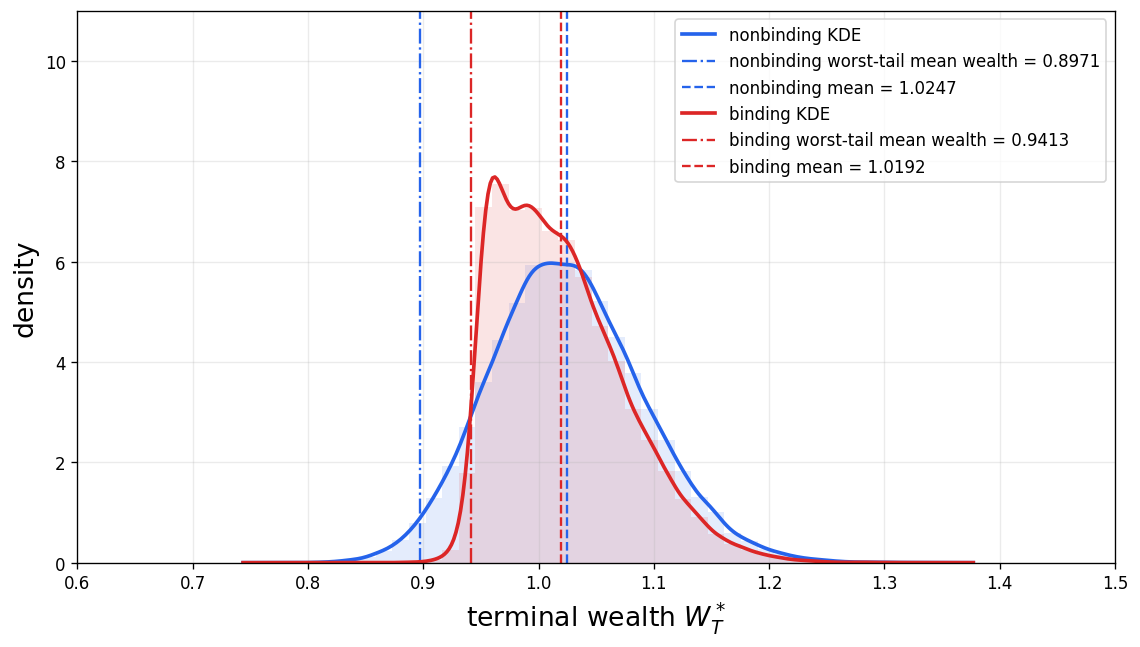

In [6]:
def plot_terminal_wealth_distribution(
    cases,
    bins_count=44,
    figsize=(9.6, 5.5),
    save_path=None,
):
    all_wealth = np.concatenate(
        [case["wealth"][:, -1] for case in cases]
    )
    padding = 0.04 * max(float(np.ptp(all_wealth)), 1.0e-3)
    grid = np.linspace(
        all_wealth.min() - padding,
        all_wealth.max() + padding,
        320,
    )
    bins = np.linspace(grid[0], grid[-1], bins_count + 1)
    fig, ax = plt.subplots(figsize=figsize)

    for case in cases:
        color = CASE_COLORS[case["name"]]
        label = CASE_LABELS[case["name"]]
        ax.hist(
            case["wealth"][:, -1],
            bins=bins,
            density=True,
            color=color,
            alpha=0.12,
            edgecolor="none",
        )
        ax.plot(
            grid,
            gaussian_kde_1d(case["wealth"][:, -1], grid),
            color=color,
            linewidth=2.2,
            label=f"{label} KDE",
        )
        ax.axvline(
            case["lower_tail_cvar"],
            color=color,
            linestyle="-.",
            linewidth=1.4,
            label=f"{label} worst-tail mean wealth = {case['lower_tail_cvar']:.4f}",
        )
        terminal_mean = float(np.mean(case["wealth"][:, -1]))
        ax.axvline(
            terminal_mean,
            color=color,
            linestyle="--",
            linewidth=1.4,
            label=f"{label} mean = {terminal_mean:.4f}",
        )

    ax.set_xlabel(r"terminal wealth $W_T^*$", fontsize=16)
    ax.set_xlim(0.6,1.5)
    ax.set_ylim(0.0, 11.0)
    ax.set_ylabel("density", fontsize=16)
    ax.legend(loc="upper right", frameon=True, fontsize=10)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_terminal, ax_terminal = plot_terminal_wealth_distribution(
    cases, save_path=FIGURE_DIR / "linear_w_dist.png"
)


## Plot 2. Dollar Risky Exposure


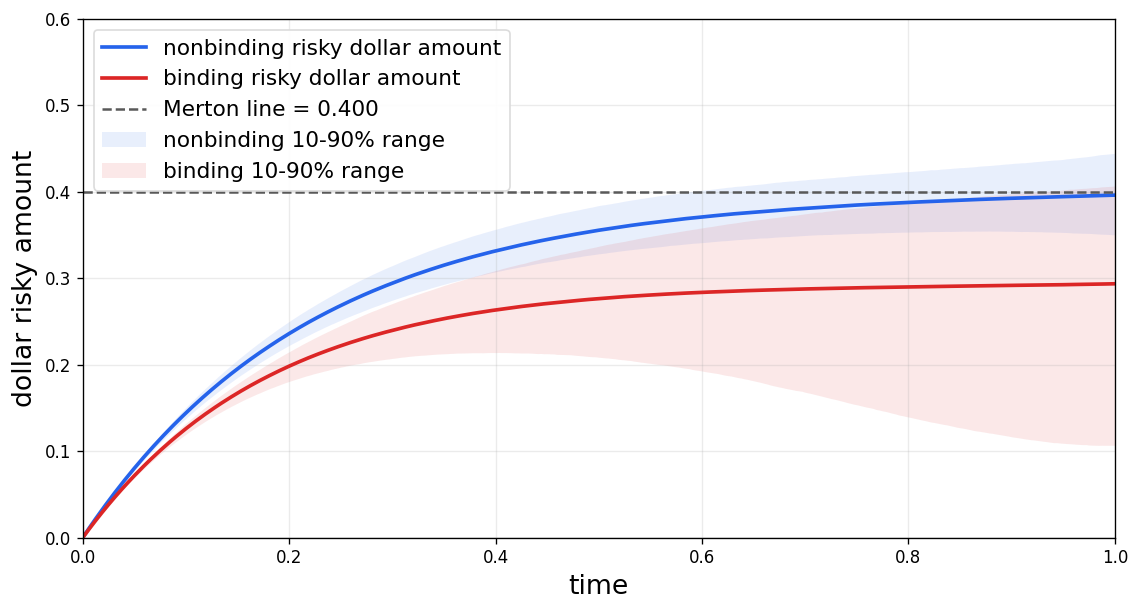

In [7]:
def plot_exposure_trajectory(cases, figsize=(9.6, 5.2), include_band=True, save_path=None):
    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        name = case["name"]
        color = CASE_COLORS.get(name, "black")
        label = CASE_LABELS.get(name, name)
        exposure_paths = case["dollar_exposure_paths"]
        t = np.linspace(0.0, case["horizon"], exposure_paths.shape[1])
        mean_exposure = np.mean(exposure_paths, axis=0)
        q10, q90 = np.quantile(exposure_paths, [0.10, 0.90], axis=0)
        if include_band:
            ax.fill_between(t, q10, q90, color=color, alpha=0.10, linewidth=0)
        ax.plot(
            t,
            mean_exposure,
            color=color,
            linewidth=2.2,
            label=f"{label} risky dollar amount",
        )

    ax.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax.axhline(
        FRICTIONLESS_MERTON_X,
        color="0.35",
        linestyle="--",
        linewidth=1.5,
        label=f"Merton line = {FRICTIONLESS_MERTON_X:.3f}",
    )
    ax.set_xlim(0.0, max(case["horizon"] for case in cases))
    ax.set_ylim(0.0, 0.6)
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel("dollar risky amount", fontsize=16)
    handles = ax.get_legend_handles_labels()[0]
    if include_band:
        handles += [
            Patch(
                facecolor=CASE_COLORS.get(case["name"], "black"),
                alpha=0.10,
                edgecolor="none",
                label=(
                    f"{CASE_LABELS.get(case['name'], case['name'])} 10-90% range"
                ),
            )
            for case in cases
        ]
    ax.legend(
        handles=handles,
        loc="upper left",
        frameon=True,
        framealpha=0.92,
        edgecolor="0.85",
        fontsize=13,
    )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_exposure, ax_exposure = plot_exposure_trajectory(
    cases, save_path=FIGURE_DIR / "linear_exposure.png"
)


## Plot 3. Wealth CVaR Over Time


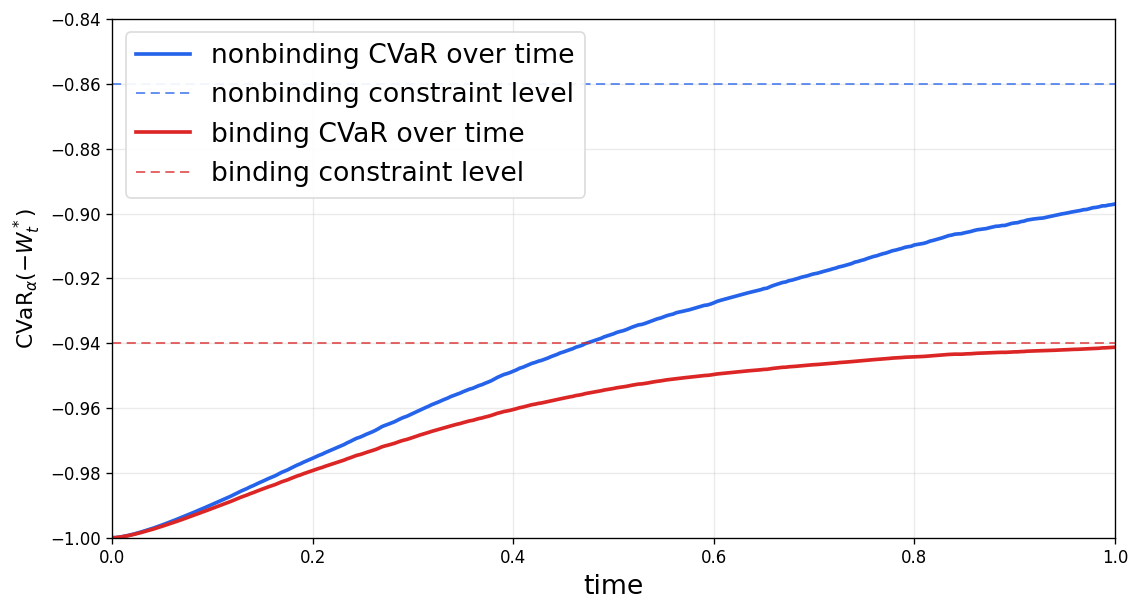

In [8]:
def plot_wealth_cvar_over_time(cases, figsize=(9.6, 5.2), save_path=None):
    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        name = case["name"]
        color = CASE_COLORS.get(name, "black")
        label = CASE_LABELS.get(name, name)
        wealth_cvar = case["cvar_path"]
        terminal_gap = abs(-wealth_cvar[-1] - case["loss_cvar"])
        if terminal_gap > 1.0e-12:
            raise AssertionError(
                f"{name}: table/figure terminal CVaR mismatch "
                f"({terminal_gap:.3e})"
            )
        t = np.linspace(0.0, case["horizon"], wealth_cvar.size)
        ax.plot(t, -wealth_cvar, color=color, linewidth=2.2, label=f"{label} CVaR over time")
        ax.axhline(
            case["cvar_limit"],
            color=color,
            linewidth=1.1,
            linestyle=(0, (5, 3)),
            alpha=0.75,
            label=f"{label} constraint level",
        )

    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"CVaR$_\alpha(-W_t^*)$", fontsize=13)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-1.0, -0.84)
    ax.legend(loc="upper left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_cvar_time, ax_cvar_time = plot_wealth_cvar_over_time(
    cases, save_path=FIGURE_DIR / "linear_cvar.png"
)


## Plot 4. Good And Bad Market Paths

This matches the two-panel wealth and dollar-risky-amount layout in
`Complete_Market_Golden.ipynb`.


good path index=5005, S_T=1.3171, late phi=0.4000, Merton=0.4000
bad path index=7041, S_T=0.7266, late phi=0.0644


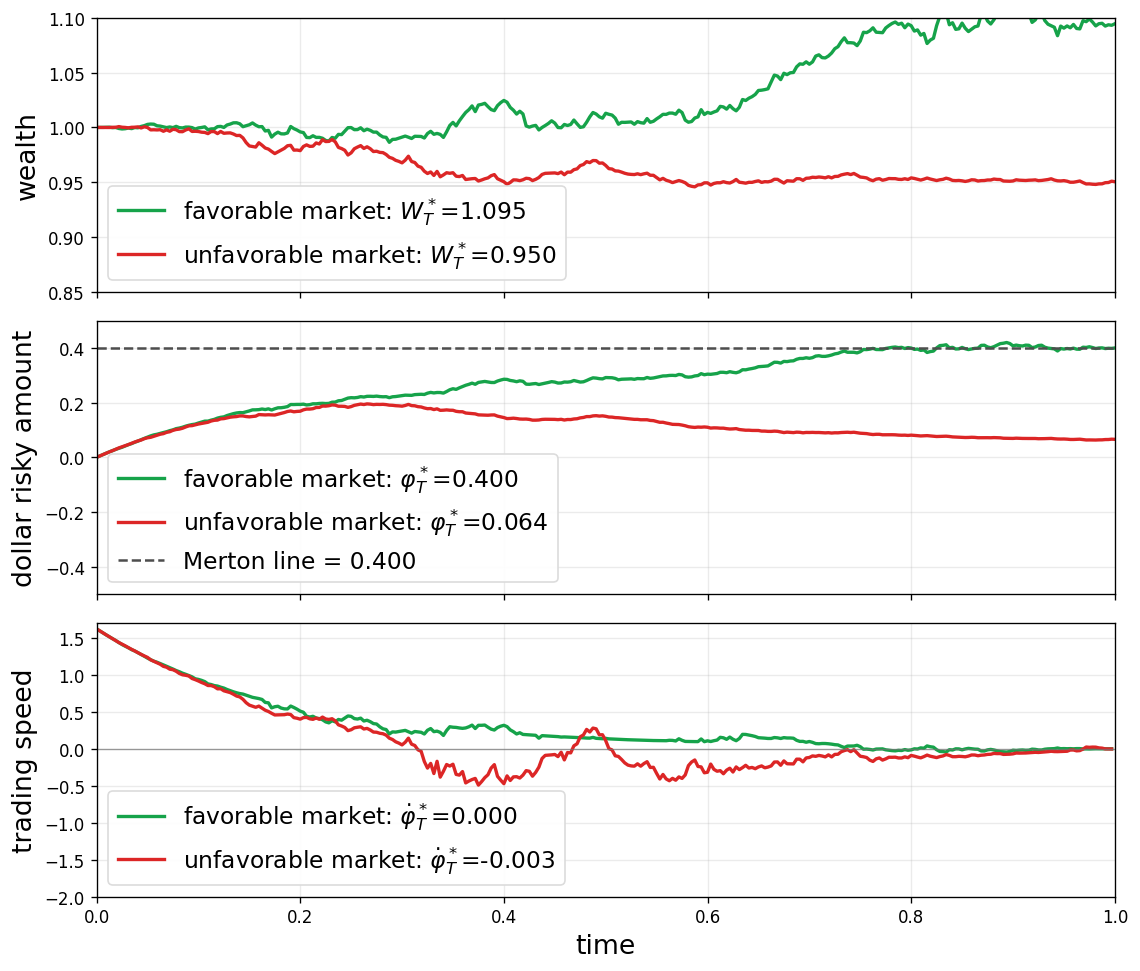

In [9]:
def select_good_bad_market_paths(stock_paths, exposure_paths, merton_value, maturity_window=10):
    terminal_stock = stock_paths[:, -1]
    late_exposure = exposure_paths[:, -maturity_window:].mean(axis=1)

    good_candidates = np.where(terminal_stock >= np.quantile(terminal_stock, 0.75))[0]
    if good_candidates.size == 0:
        good_candidates = np.arange(terminal_stock.size)
    good_idx = good_candidates[
        np.argmin(np.abs(late_exposure[good_candidates] - merton_value))
    ]

    bad_candidates = np.where(terminal_stock <= np.quantile(terminal_stock, 0.25))[0]
    if bad_candidates.size == 0:
        bad_candidates = np.arange(terminal_stock.size)
    bad_idx = bad_candidates[np.argmin(late_exposure[bad_candidates])]
    if bad_idx == good_idx:
        order = bad_candidates[np.argsort(late_exposure[bad_candidates])]
        bad_idx = order[1] if order.size > 1 else bad_idx
    return int(good_idx), int(bad_idx)


def plot_good_bad_market_paths(
    active_case,
    path_count=8000,
    maturity_window=10,
    figsize=(9.6, 6.2),
    save_path=None,
):
    if path_count < 2 or not 1 <= maturity_window <= active_case["params"].steps + 1:
        raise ValueError("invalid path_count or maturity_window")
    plot_params = replace(
        active_case["params"],
        samples=path_count,
        seed=active_case["params"].seed + 252000,
    )
    d_brownian_plot = generate_brownian_increments(plot_params)
    wealth_paths, exposure_paths, control_paths = simulate_feedback_policy(
        active_case["wealth_grid"],
        active_case["exposure_grid"],
        active_case["policy_grid"],
        d_brownian_plot,
        plot_params,
    )
    stock_paths = stock_paths_from_brownian(d_brownian_plot, plot_params)
    merton_value = float(FRICTIONLESS_MERTON_X)
    good_idx, bad_idx = select_good_bad_market_paths(
        stock_paths, exposure_paths, merton_value, maturity_window=maturity_window
    )

    t = np.linspace(0.0, plot_params.horizon, plot_params.steps + 1)
    good_color = "#16a34a"
    bad_color = CASE_COLORS.get("active", "#dc2626")
    fig, (ax_stock, ax_exposure, ax_control) = plt.subplots(
        3, 1, figsize=(figsize[0], 8.2), sharex=True
    )
    for idx, color, label in [
        (good_idx, good_color, "favorable market"),
        (bad_idx, bad_color, "unfavorable market"),
    ]:
        late_exposure = float(exposure_paths[idx, -maturity_window:].mean())
        ax_stock.plot(
            t,
            wealth_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$W_T^*$="+f"{wealth_paths[idx, -1]:.3f}",
        )
        ax_exposure.plot(
            t,
            exposure_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$\varphi_T^*$="+f"{late_exposure:.3f}",
        )
        ax_control.plot(
            t[:-1],
            control_paths[idx],
            color=color,
            linewidth=2.0,
            label=f"{label}: "+r"$\dot\varphi_T^*$"+f"={control_paths[idx,-1]:.3f}",
        )

    ax_exposure.axhline(
        merton_value,
        color="0.30",
        linewidth=1.5,
        linestyle="--",
        label=f"Merton line = {merton_value:.3f}",
    )
    ax_stock.set_ylabel("wealth", fontsize=16)
    ax_exposure.set_ylabel("dollar risky amount", fontsize=16)
    ax_control.set_ylabel(r"trading speed", fontsize=16)
    ax_control.set_xlabel("time", fontsize=16)
    ax_stock.set_ylim(0.85, 1.10)
    ax_exposure.set_ylim(-0.5, 0.5)
    ax_control.set_ylim(-2.0, 1.70)
    ax_control.set_xlim(0.0, 1.0)
    ax_control.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax_stock.legend(
        loc="lower left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=14
    )
    ax_exposure.legend(
        loc="lower left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=14
    )
    ax_control.legend(
        loc="lower left", frameon=True, framealpha=0.92, edgecolor="0.85", fontsize=14
    )
    fig.tight_layout()

    print(
        f"good path index={good_idx}, S_T={stock_paths[good_idx, -1]:.4f}, "
        f"late phi={exposure_paths[good_idx, -maturity_window:].mean():.4f}, "
        f"Merton={merton_value:.4f}"
    )
    print(
        f"bad path index={bad_idx}, S_T={stock_paths[bad_idx, -1]:.4f}, "
        f"late phi={exposure_paths[bad_idx, -maturity_window:].mean():.4f}"
    )
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, (ax_stock, ax_exposure, ax_control), (good_idx, bad_idx)


active_case = next(case for case in cases if case["name"] == "active")
fig_good_bad, axes_good_bad, selected_good_bad_paths = plot_good_bad_market_paths(
    active_case, save_path=FIGURE_DIR / "linear_sample.png"
)


## Plot 5. Control Trajectory

This mirrors Plot 2 for the exposure-rate control `v_t`, showing the inactive
and active means together with both 10–90% pathwise ranges.


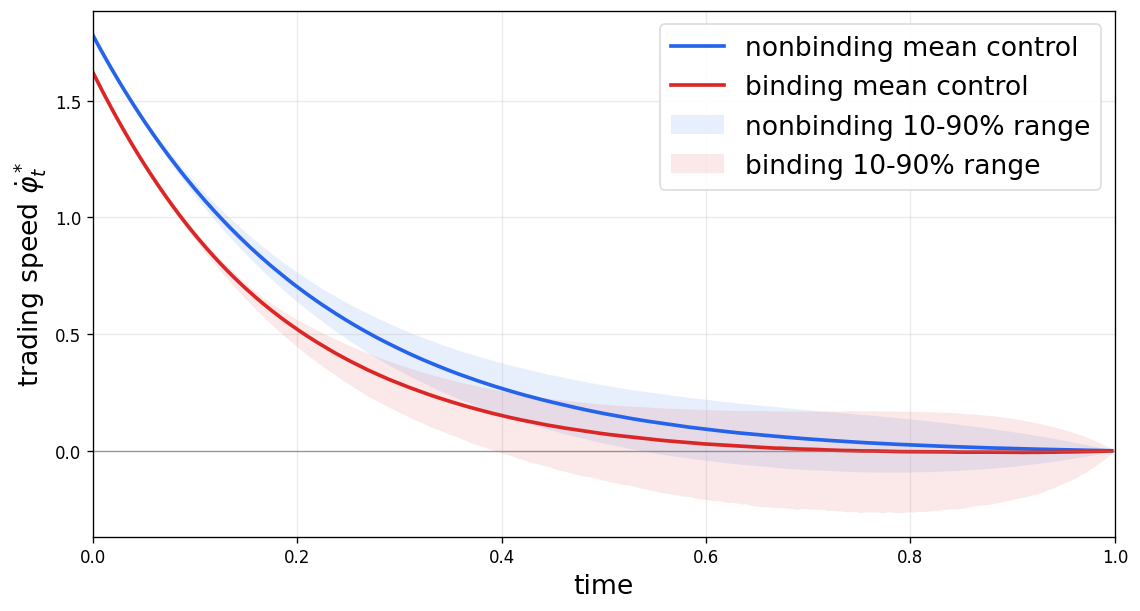

In [10]:
def plot_control_trajectory(cases, figsize=(9.6, 5.2), include_band=True, save_path=None):
    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        name = case["name"]
        color = CASE_COLORS.get(name, "black")
        label = CASE_LABELS.get(name, name)
        control_paths = case["trade_rate_paths"]
        t = np.linspace(0.0, case["horizon"], control_paths.shape[1], endpoint=False)
        mean_control = np.mean(control_paths, axis=0)
        q10, q90 = np.quantile(control_paths, [0.10, 0.90], axis=0)

        if include_band:
            ax.fill_between(t, q10, q90, color=color, alpha=0.10, linewidth=0)
        ax.plot(t, mean_control, color=color, linewidth=2.2, label=f"{label} mean control")

    ax.axhline(0.0, color="0.45", linewidth=0.8, alpha=0.7)
    ax.set_xlim(0.0, max(case["horizon"] for case in cases))
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"trading speed $\dot\varphi_t^*$", fontsize=16)
    handles = ax.get_legend_handles_labels()[0]
    if include_band:
        handles = handles + [
            Patch(
                facecolor=CASE_COLORS.get(case["name"], "black"),
                alpha=0.10,
                edgecolor="none",
                label=f"{CASE_LABELS.get(case['name'], case['name'])} 10-90% range",
            )
            for case in cases
        ]
    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
        framealpha=0.92,
        edgecolor="0.85",
        fontsize=16,
    )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_control, ax_control = plot_control_trajectory(
    cases, save_path=FIGURE_DIR / "linear_control.png"
)
